# **Asignatura**: Aprendizaje Automático

**Práctica 2**: Aprendizaje No Supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 25 de Abril de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Laura Salas López



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Agrupamiento / Clustering (5 puntos)**

## 1.1 Contexto: Segmentación de Clientes en un Centro Comercial

El equipo de marketing de un gran centro comercial quiere entender mejor a sus clientes para diseñar estrategias personalizadas. Tienen datos históricos de clientes que incluyen edad, género, ingresos anuales y una "Puntuación de Gasto" (Spending Score) asignada por el centro basada en el comportamiento del cliente y la lealtad.

**Objetivo:** Utilizar técnicas de agrupamiento (Clustering) para identificar segmentos de clientes (perfiles) que compartan comportamientos similares.

**Variables:**
- `CustomerID`: ID único del cliente.
- `Gender`: Género.
- `Age`: Edad.
- `Annual Income (k$)`: Ingresos anuales en miles de dólares.
- `Spending Score (1-100)`: Puntuación de gasto (mayor puntuación = gasta más).

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Carga de datos Clustering (Mall Customers)
url='https://drive.google.com/file/d/1MrDJ-ZCgaTqxc34nAcCt0RBqOncAFTc6/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df_clustering = pd.read_csv(url)

print("Datos de Clientes cargados:")
display(df_clustering.head())

Datos de Clientes cargados:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [50]:
# Silencio los warnings que aparecen al ejecutar algunas celdas
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

## 1.2 Tareas de Análisis y Modelado

El alumno debe realizar las siguientes tareas documentadas:

1.  **EDA y Preprocesado:**
    * Analice la distribución de las variables (histogramas/boxplots).
    * ¿Es necesario escalar los datos? Justifique su respuesta y aplique `StandardScaler` si procede.
    * **Nota:** Para visualizar los clusters en 2D fácilmente, se recomienda utilizar principalmente las variables `Annual Income` y `Spending Score` para el entrenamiento, aunque puede probar con más.

2.  **Algoritmo K-Means:**
    * Utilice el **Método del Codo (Elbow Method)** para determinar el número óptimo de clusters ($k$). Muestre la gráfica de la inercia.
    * Entrene el modelo con el $k$ elegido.
    * Visualice los clusters resultantes y sus centroides.

3.  **Algoritmo Jerárquico (Aglomerativo) o DBSCAN:**
    * Seleccione un segundo algoritmo (DBSCAN o Clustering Jerárquico).
    * Ajuste sus hiperparámetros (ej: `eps` y `min_samples` para DBSCAN).
    * Compare visualmente los resultados con K-Means.

4.  **Interpretación (Crucial):**
    * Describa los grupos encontrados. Ejemplo: "Grupo 1: Clientes con altos ingresos pero bajo gasto (Ahorradores)".

### 1. EDA y Preprocesado

En esta sección, realizaremos un Análisis Exploratorio de Datos (EDA) para comprender la distribución de las variables numéricas y detectar posibles valores atípicos (outliers). Esto nos permitirá justificar el preprocesamiento matemático necesario antes de aplicar los algoritmos de clustering.

In [51]:
df_clustering.info()
df_clustering.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Al observar la estructura del dataset, notamos que la variable `CustomerID` es un identificador único sin valor predictivo ni de agrupación, por lo que no se tendrá en cuenta para el análisis.

Por otro lado, los rangos de las características difieren notablemente, lo que nos obliga a usar `StandardScaler` para evitar que variables con magnitudes altas dominen el modelo.

También habrá que transformar la columna `Gender` para poder trabajar con ella.

Comenzaremos visualizando la distribución de los datos mediante boxplots e histogramas para extraer información preliminar antes de aplicar transformaciones.

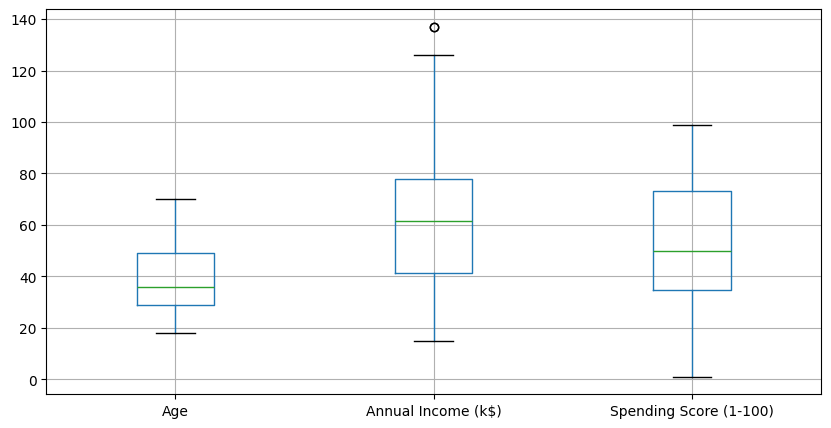

In [52]:
variables = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

plt.figure(figsize=(10, 5))
df_clustering[variables].boxplot()
plt.show()

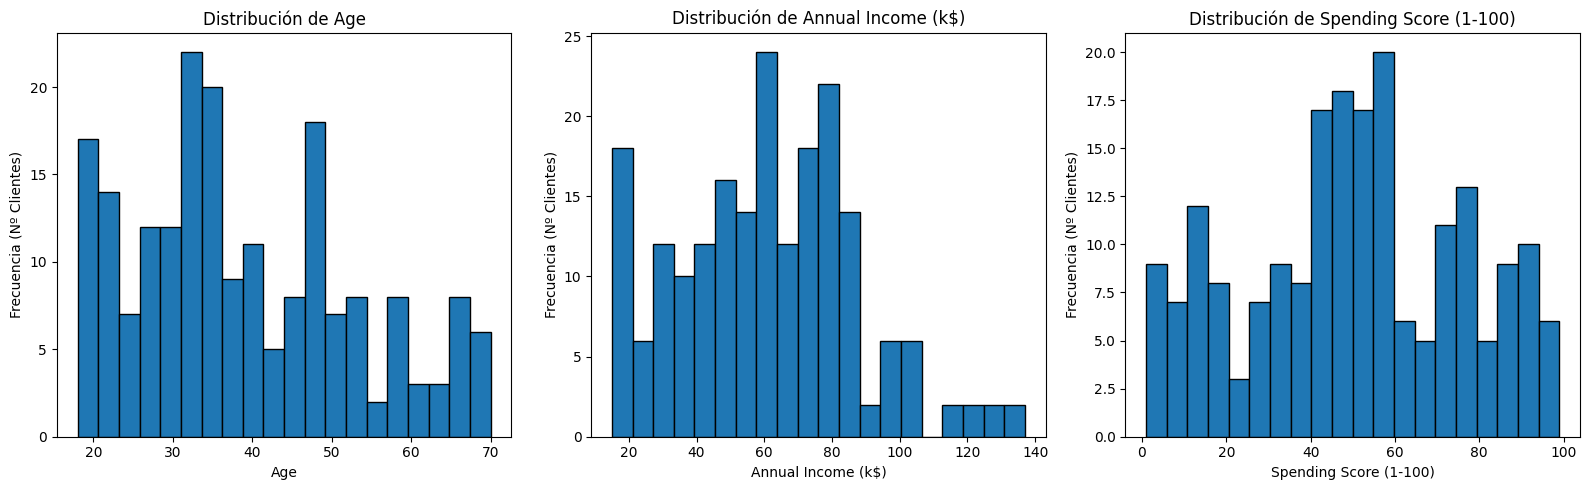

In [53]:
plt.figure(figsize=(16, 5))

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)

    plt.hist(df_clustering[var], bins=20, edgecolor='black')

    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia (Nº Clientes)')

plt.tight_layout()
plt.show()

El análisis de los boxplots revela la presencia de outliers en la variable `Annual Income`.

En cuanto a los histogramas, podemos observar lo siguiente:

- `Age`: ligeramente sesgada hacia clientes más jóvenes.

- `Annual Income`: se concentra en rangos medios-bajos.

- `Spending Score`: la presencia de diferentes picos sugiere la existencia de distintos perfiles de compradores.

Dado que los algoritmos basados en distancias (como K-Means) son muy sensibles a valores atípicos, he decidido eliminar el outlier de ingresos utilizando el método del Rango Intercuartílico (IQR). Comparando los resultados tras quitarlo y sin quitarlo, se confirma que esta limpieza mejora la cohesión de los clústeres resultantes.

In [54]:
# Calculamos los cuartiles
Q1 = df_clustering['Annual Income (k$)'].quantile(0.25)
Q3 = df_clustering['Annual Income (k$)'].quantile(0.75)
IQR = Q3 - Q1

# Calculamos el límite superior
limite_superior = Q3 + 1.5 * IQR

# Filtramos el DataFrame
df_clustering_original_len = len(df_clustering)
df_clustering = df_clustering[df_clustering['Annual Income (k$)'] <= limite_superior]

eliminados = df_clustering_original_len - len(df_clustering)
print(f"Se han eliminado {eliminados} outliers de altos ingresos.")

Se han eliminado 2 outliers de altos ingresos.


Pasamos ahora a analizar la distribución de mujeres/hombres que tenemos. Para ellos, uso `LabelEncoder` para pasar de Female/Male a 0/1.

In [55]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# guardo el resultado en una nueva columna para no perder la original
df_clustering['Gender_Num'] = label_encoder.fit_transform(df_clustering['Gender'])

print(df_clustering[['Gender', 'Gender_Num']].head())

print(label_encoder.classes_)

   Gender  Gender_Num
0    Male           1
1    Male           1
2  Female           0
3  Female           0
4  Female           0
['Female' 'Male']


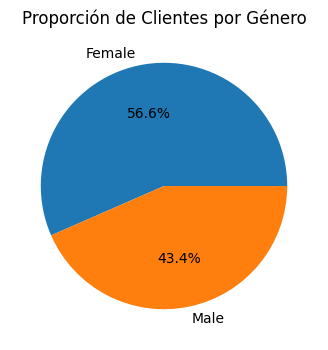

In [56]:
plt.figure(figsize=(4, 4))

df_clustering['Gender'].value_counts().plot.pie(
    autopct='%1.1f%%', # porcentaje con 1 decimal
)
plt.title('Proporción de Clientes por Género')
plt.ylabel('')
plt.show()

Se observa una distribución relativamente equilibrada entre géneros. Teniendo esto en cuenta, junto con el hecho de que los algoritmos de clustering a utilizar se basan en la distancia, decido excluir la variable `Gender` del entrenamiento. Al ser una característica binaria, introducirla en el mismo espacio que las variables continuas distorsiona la geometría del modelo, pudiendo forzar la separación de clientes con idénticos ingresos y hábitos de consumo únicamente por su género.

Pasamos a representar algunos Scatter Plot:

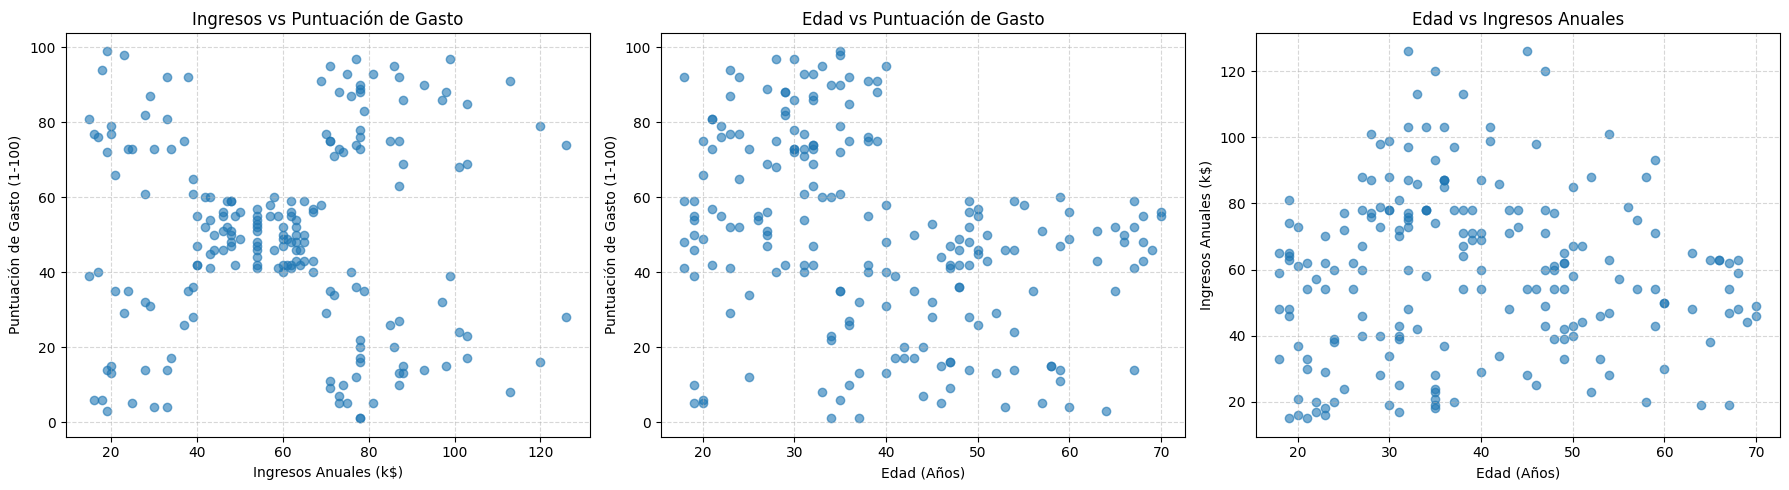

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ingresos vs Puntuación
axes[0].scatter(df_clustering['Annual Income (k$)'], df_clustering['Spending Score (1-100)'], alpha=0.6)
axes[0].set_title('Ingresos vs Puntuación de Gasto')
axes[0].set_xlabel('Ingresos Anuales (k$)')
axes[0].set_ylabel('Puntuación de Gasto (1-100)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Edad vs Puntuación
axes[1].scatter(df_clustering['Age'], df_clustering['Spending Score (1-100)'], alpha=0.6)
axes[1].set_title('Edad vs Puntuación de Gasto')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Puntuación de Gasto (1-100)')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Edad vs Ingresos
axes[2].scatter(df_clustering['Age'], df_clustering['Annual Income (k$)'], alpha=0.6)
axes[2].set_title('Edad vs Ingresos Anuales')
axes[2].set_xlabel('Edad (Años)')
axes[2].set_ylabel('Ingresos Anuales (k$)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

El primer gráfico de dispersión (Ingresos vs Gasto) revela visualmente 5 clústeres bien definidos. El segundo gráfico muestra que los clientes mayores de 40 años no superan una puntuación de gasto de 60, mientras que los más jóvenes abarcan todo el espectro. El tercer gráfico indica un pico de ingresos en la franja de 30 a 50 años.

Al no verse cluster distinguidos en los dos últimos, podemos pensar que igual la edad no es una característica crítica en este problema.

A continuación, escalaremos los datos con `StandardScaler` para preparar el entrenamiento.

In [58]:
from sklearn.preprocessing import StandardScaler

columnas_clustering = ['Age','Annual Income (k$)', 'Spending Score (1-100)']

# nos quedamos solo con esas columnas
X_original = df_clustering[columnas_clustering]

scaler = StandardScaler()

X_escalado = scaler.fit_transform(X_original)

# guardamos en un df con los nombres de columnas que teníamos
df_scaled = pd.DataFrame(X_escalado, columns=columnas_clustering)

df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.425414,-1.779171,-0.435989
1,-1.282367,-1.779171,1.199413
2,-1.353890,-1.739447,-1.720949
3,-1.139319,-1.739447,1.043661
4,-0.567131,-1.699723,-0.397051


Entrenaremos y evaluaremos los modelos en dos escenarios espaciales:
- Un espacio bidimensional (2D) con `Annual Income` y `Spending Score`.
- Un espacio tridimensional (3D) añadiendo `Age`.

La comparativa de las métricas nos permitirá confirmar la hipótesis formulada sobre el impacto de la edad.

In [59]:
# Ingresos y Puntuación
X_2d = df_scaled[['Annual Income (k$)', 'Spending Score (1-100)']]
# Edad, Ingresos y Puntuación
X_3d = df_scaled[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

### 2. Algoritmo K-Means

Empezamos aplicando el método del codo para encontrar el número óptimo de clústers.

Usaremos `n_init=10` en los parámetros de `KMeans` para que se repita el proceso de clustering 10 veces, quedándose finalmente con la mejor solución. Esto se debe a que los resultados pueden variar según dónde caigan los centroides iniciales.

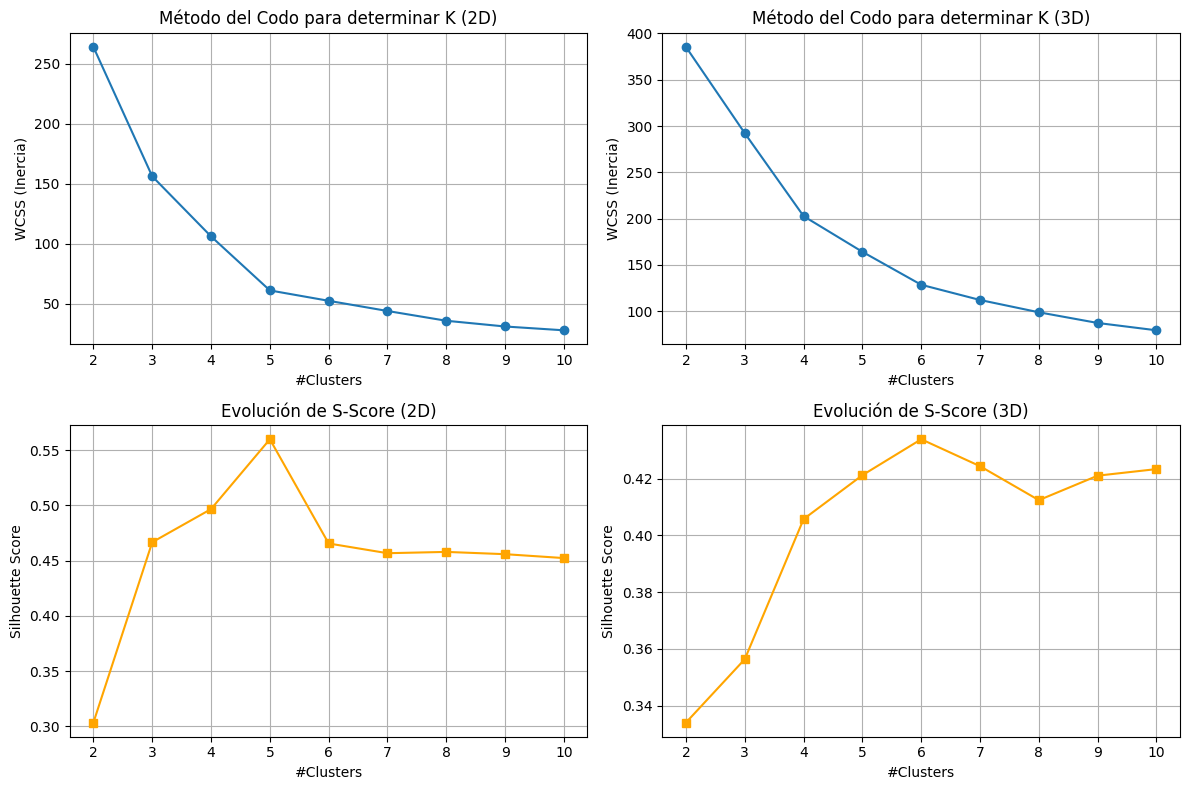

In [60]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss2= [] # Listado de WCSS para cada solución
Sscore2= [] # Listado de Silhouette Scores para cada solución

wcss3= [] # Listado de WCSS para cada solución
Sscore3= [] # Listado de Silhouette Scores para cada solución

# Generamos soluciones desde 2 a max_clusters clusters
max_clusters= 10
for num_clusters in range(2, max_clusters+1):

    # Instanciamos y entrenamos el modelo KMeans de sklearn tanto para X_2d como para X_3d
    kmeans2 = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans2.fit(X_2d)

    kmeans3 = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans3.fit(X_3d)

    # Calculamos el WCSS de la solución
    wcss2.append(kmeans2.inertia_)
    wcss3.append(kmeans3.inertia_)

    # Cálculo de la S-Score (necesitamos los datos y las etiquetas asignadas)
    # kmeans.labels_ contiene a qué cluster ha ido cada cliente
    score2 = silhouette_score(X_2d, kmeans2.labels_)
    Sscore2.append(score2)

    score3 = silhouette_score(X_3d, kmeans3.labels_)
    Sscore3.append(score3)


# mostramos las graficas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))


# Gráficas de WCSS (Método del Codo)

# WCSS (2D)
axes[0, 0].plot(np.arange(2, max_clusters+1), wcss2, marker='o')
axes[0, 0].set_xlabel('#Clusters')
axes[0, 0].set_ylabel('WCSS (Inercia)')
axes[0, 0].set_title('Método del Codo para determinar K (2D)')
axes[0, 0].grid()

# WCSS (3D)
axes[0, 1].plot(np.arange(2, max_clusters+1), wcss3, marker='o')
axes[0, 1].set_xlabel('#Clusters')
axes[0, 1].set_ylabel('WCSS (Inercia)')
axes[0, 1].set_title('Método del Codo para determinar K (3D)')
axes[0, 1].grid()


# Gráficas de Silhouette Score

# S-Score (2D)
axes[1, 0].plot(np.arange(2, max_clusters+1), Sscore2, marker='s', color='orange')
axes[1, 0].set_xlabel('#Clusters')
axes[1, 0].set_ylabel('Silhouette Score')
axes[1, 0].set_title('Evolución de S-Score (2D)')
axes[1, 0].grid()

# S-Score (3D)
axes[1, 1].plot(np.arange(2, max_clusters+1), Sscore3, marker='s', color='orange')
axes[1, 1].set_xlabel('#Clusters')
axes[1, 1].set_ylabel('Silhouette Score')
axes[1, 1].set_title('Evolución de S-Score (3D)')
axes[1, 1].grid()


plt.tight_layout()
plt.show()

Para el subconjunto bidimensional (X_2d), la gráfica de inercia (WCSS) muestra un 'codo' pronunciado en K=5, coincidiendo exactamente con el pico máximo del Silhouette Score. Por tanto, establecemos K=5 como el número óptimo.

En el espacio tridimensional (X_3d), la gráfica sugiere K=6. Sin embargo, probaremos también con K=5.

--- COMPARATIVA DE SILHOUETTE SCORE ---
KMeans 2D (K=5): 0.5599
KMeans 3D (K=5): 0.4212
KMeans 3D (K=6): 0.4338



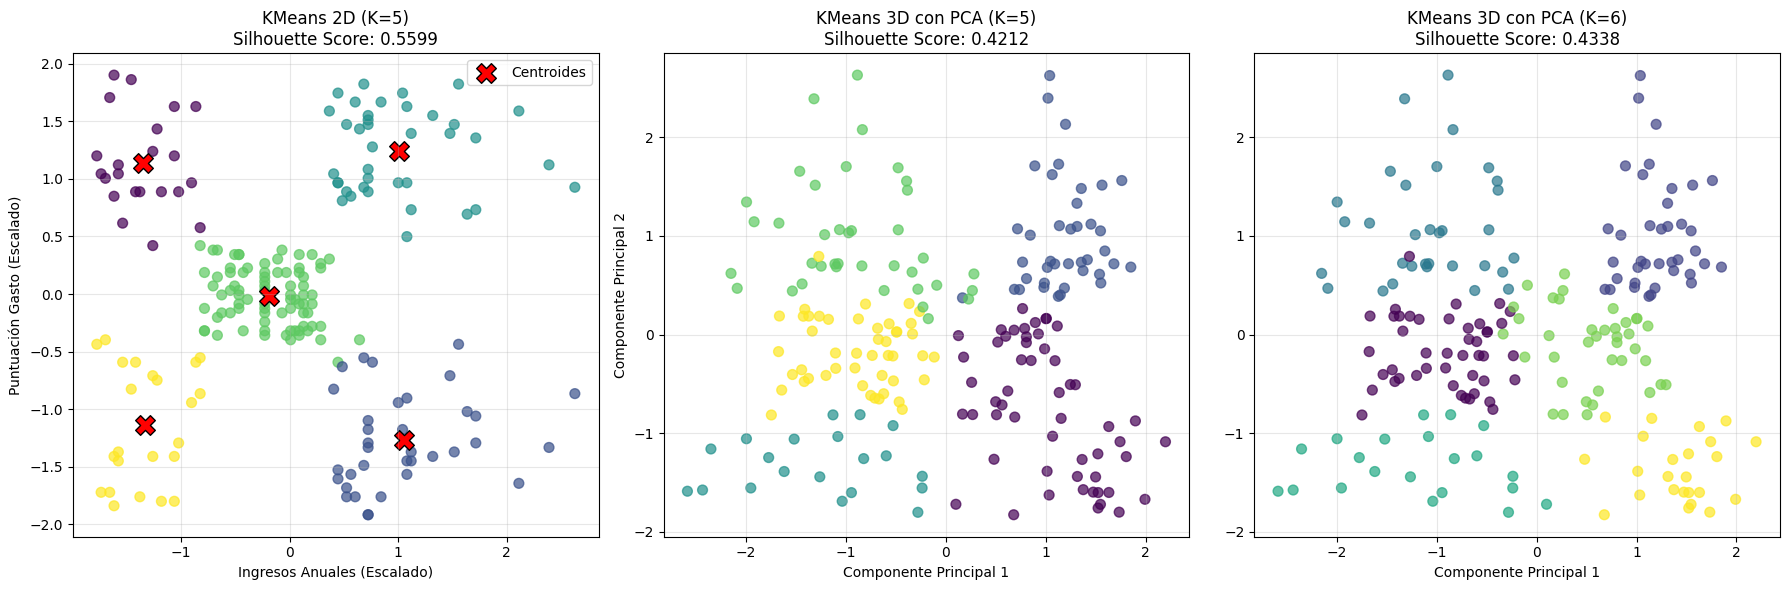

In [61]:
from sklearn.decomposition import PCA

# Entrenamos los modelos
kmeans_2 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_2d)
kmeans_3_k5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_3d)
kmeans_3_k6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_3d)


# Calculamos los Silhouette Scores
sil_2d_k5 = silhouette_score(X_2d, kmeans_2.labels_)
sil_3d_k5 = silhouette_score(X_3d, kmeans_3_k5.labels_)
sil_3d_k6 = silhouette_score(X_3d, kmeans_3_k6.labels_)

print("--- COMPARATIVA DE SILHOUETTE SCORE ---")
print(f"KMeans 2D (K=5): {sil_2d_k5:.4f}")
print(f"KMeans 3D (K=5): {sil_3d_k5:.4f}")
print(f"KMeans 3D (K=6): {sil_3d_k6:.4f}\n")

# Usamos PCA para poder visualizar los clusters de X_3d en 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_3d)


# Dibujamos las gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# KMeans 2D (K=5)
axes[0].scatter(np.array(X_2d)[:, 0], np.array(X_2d)[:, 1], c=kmeans_2.labels_, cmap='viridis', s=50, alpha=0.7)
# Pintamos también los centroides
axes[0].scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1],
                c='red', s=200, marker='X', edgecolor='black', label='Centroides')
axes[0].set_title(f'KMeans 2D (K=5)\nSilhouette Score: {sil_2d_k5:.4f}')
axes[0].set_xlabel('Ingresos Anuales (Escalado)')
axes[0].set_ylabel('Puntuación Gasto (Escalado)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# KMeans 3D (K=5)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_3_k5.labels_, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title(f'KMeans 3D con PCA (K=5)\nSilhouette Score: {sil_3d_k5:.4f}')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].grid(alpha=0.3)

# KMeans 3D (K=6)
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_3_k6.labels_, cmap='viridis', s=50, alpha=0.7)
axes[2].set_title(f'KMeans 3D con PCA (K=6)\nSilhouette Score: {sil_3d_k6:.4f}')
axes[2].set_xlabel('Componente Principal 1')
axes[2].grid(alpha=0.3)


plt.tight_layout()
plt.show()

Tras evaluar ambas opciones, el modelo 2D con K=5 obtiene matemáticamente el mejor Silhouette Score, confirmando analíticamente nuestra hipótesis inicial: la introducción de la variable `Age` aporta ruido espacial y empeora la cohesión de los grupos.

### 3. Algoritmo Jerárquico (Aglomerativo)

He seleccionado el Algoritmo Jerárquico como segundo algoritmo porque los resultados obtenidos con `K-Means` muestran que los clusters presentan formas rectangulares, por lo que `DBSCAN` no va a aportar demasiada información, ya que no tenemos formas extrañas con alta densidad de puntos.

Al igual que antes, empezamos buscando el número óptimo de clusters.

Usaremos los siguientes parámetros de `AgglomerativeClustering`:

- `metric='euclidean'`: porque al trabajar con variables continuas, considero que la distancia euclídea es la forma más natural de saber si dos clientes están cerca en función de sus características.

- `linkage='ward'`: porque busca minimizar la varianza de los clusters a medida que los fusiona. Usando la distancia euclídea como métrica, tiene sentido usar este criterio.

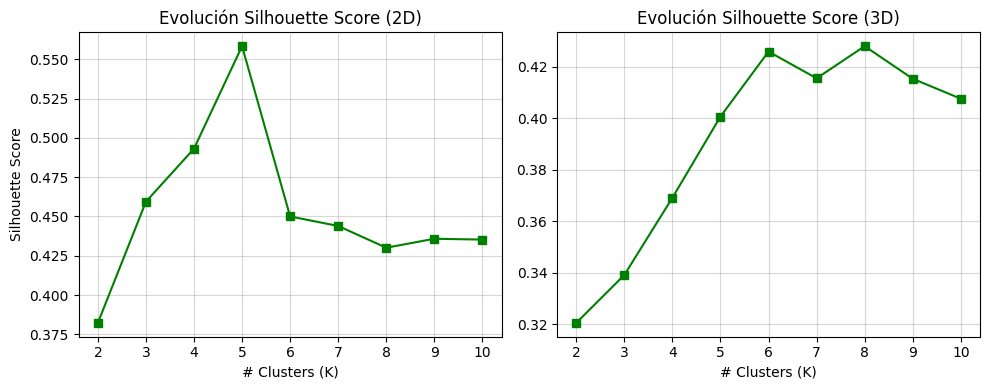

In [62]:
from sklearn.cluster import AgglomerativeClustering

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sil_hc_2d = []
sil_hc_3d = []
rango_k = range(2, 11)

# Bucle para entrenar modelos desde K=2 hasta K=10
for k in rango_k:
    hc2 = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    etiquetas_2d = hc2.fit_predict(X_2d)
    sil_hc_2d.append(silhouette_score(X_2d, etiquetas_2d))

    hc3 = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    etiquetas_3d = hc3.fit_predict(X_3d)
    sil_hc_3d.append(silhouette_score(X_3d, etiquetas_3d))

# 2D
axes[0].plot(rango_k, sil_hc_2d, marker='s', color='green')
axes[0].set_title('Evolución Silhouette Score (2D)')
axes[0].set_xlabel('# Clusters (K)')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True, alpha=0.5)

# 3D
axes[1].plot(rango_k, sil_hc_3d, marker='s', color='green')
axes[1].set_title('Evolución Silhouette Score (3D)')
axes[1].set_xlabel('# Clusters (K)')
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Analizando la evolución del Silhouette Score, corroboramos nuevamente que el modelo bidimensional (`X_2d`) supera al tridimensional, por lo que se procederá al entrenamiento final utilizando únicamente Ingresos y Gasto.

Silhouette Score: 0.5584


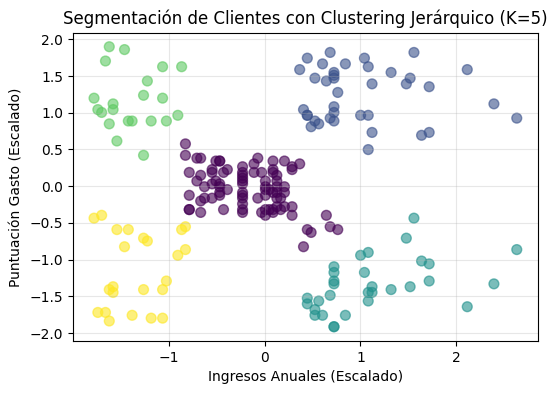

In [63]:
hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')

# Entrenamos y predecimos
y_hc = hc.fit_predict(X_2d)

# Calculamos el Silhouette Score
sil_hc = silhouette_score(X_2d, y_hc)
print(f"Silhouette Score: {sil_hc:.4f}")

# Visualizamos los clusters
plt.figure(figsize=(6, 4))

plt.scatter(X_2d['Annual Income (k$)'], X_2d['Spending Score (1-100)'],
            c=y_hc, cmap='viridis', s=50, alpha=0.6)

plt.title('Segmentación de Clientes con Clustering Jerárquico (K=5)')
plt.xlabel('Ingresos Anuales (Escalado)')
plt.ylabel('Puntuación Gasto (Escalado)')
plt.grid(True, alpha=0.3)
plt.show()

### Comparación

Por último, procedemos a comparar el mejor resultado de `KMeans` (2 variables y K=5) con el mejor de `AgglomerativeClustering` (2 variables y K=5).

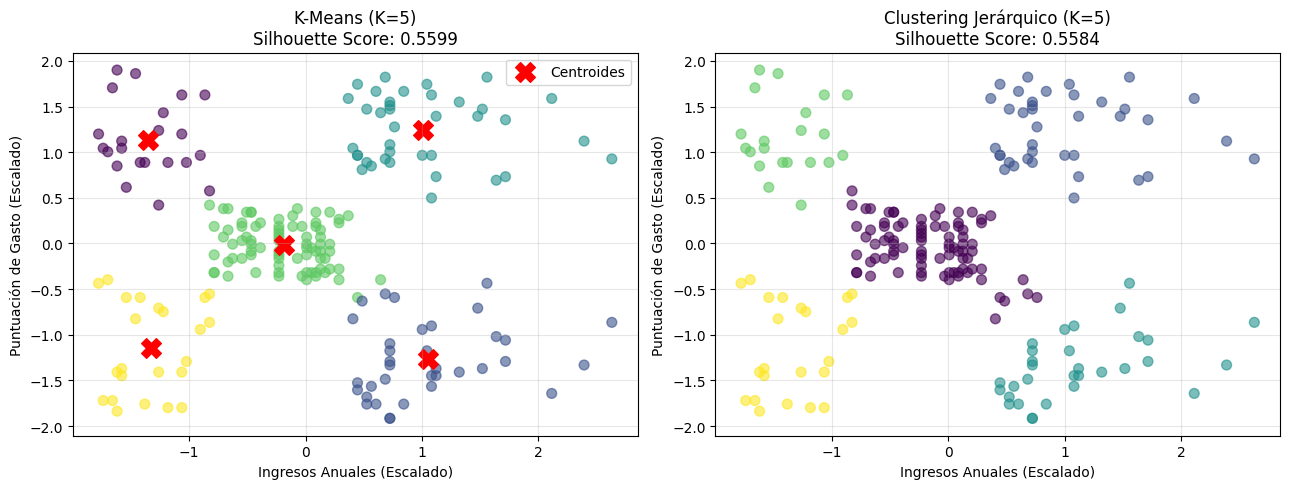

In [64]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

X_2d_arr = np.array(X_2d)

# K-Means
ax1.scatter(X_2d_arr[:, 0], X_2d_arr[:, 1], c=kmeans_2.labels_, cmap='viridis', alpha=0.6, s=50)

# Añadimos los centroides
centroides = kmeans_2.cluster_centers_
ax1.scatter(centroides[:, 0], centroides[:, 1], c='red', s=200, marker='X', label='Centroides')

ax1.set_title(f'K-Means (K=5)\nSilhouette Score: {sil_2d_k5:.4f}')
ax1.set_xlabel('Ingresos Anuales (Escalado)')
ax1.set_ylabel('Puntuación de Gasto (Escalado)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Clustering Jerárquico
ax2.scatter(X_2d_arr[:, 0], X_2d_arr[:, 1], c=y_hc, cmap='viridis', alpha=0.6, s=50)

ax2.set_title(f'Clustering Jerárquico (K=5)\nSilhouette Score: {sil_hc:.4f}')
ax2.set_xlabel('Ingresos Anuales (Escalado)')
ax2.set_ylabel('Puntuación de Gasto (Escalado)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación

Basándonos en la distribución bidimensional de los modelos ganadores, podemos identificar 5 perfiles de consumidores claramente diferenciados:

- Los ahorradores (Altos ingresos, Bajo gasto): clientes con gran capacidad económica pero muy conservadores en sus compras.

- Los VIP (Altos ingresos, Alto gasto): tienen dinero y les gusta gastarlo.

- El promedio (Ingresos medios, Gasto medio): el grupo más numeroso situado en el centro del gráfico. Clientes estándar.

- Los prudentes (Bajos ingresos, Bajo gasto): clientes con poco presupuesto que compran estrictamente lo necesario.

- Los impulsivos (Bajos ingresos, Alto gasto): un grupo de riesgo financiero. Gastan mucho más de lo que sus ingresos sugieren.

## **Conclusiones Generales**

Tras la ejecución y evaluación de los algoritmos de aprendizaje no supervisado, extraemos las siguientes conclusiones:

**1. La penalización de la dimensionalidad (El impacto de la Edad y el Género):**

Al explorar los datos, se demostró que añadir variables adicionales no siempre mejora el modelo. Incluir la variable `Age` redujo significativamente la calidad de los grupos (bajando el Silhouette Score a ~0.42). Esto nos indica que los hábitos de gasto en este centro comercial son independientes de la edad (hay jóvenes y mayores en todos los rangos de gasto). Asimismo, la variable binaria `Gender` distorsionaba el cálculo de distancias euclídeas, por lo que el modelo óptimo se consolidó utilizando únicamente dos dimensiones continuas: Ingresos y Puntuación de Gasto.

**2. Robustez geométrica (K-Means vs. Clustering Jerárquico)**

Se han evaluado dos algoritmos:

- **K-Means:** enfoque divisivo basado en la minimización de la varianza interna (inercia) mediante la actualización iterativa de centroides.

- **Clustering Jerárquico:** enfoque aglomerativo que une iterativamente los puntos más cercanos basándose en la distancia euclídea y buscando también minimizar la varianza interna.

Ambos algoritmos han convergido visual y numéricamente en la misma estructura de 5 clústeres. El hecho de que dos enfoques distintos descubran los mismos patrones nos garantiza que estos grupos son una estructura real en la base de datos de los clientes.

**3. Interpretación de Métricas (Silhouette Score)**

El modelo K-Means obtuvo un Silhouette Score de 0.5599, mientras que el Jerárquico obtuvo 0.5584. Este valor nos indica que los clientes dentro de un mismo grupo son muy similares entre sí (alta cohesión) y que las fronteras entre los distintos perfiles de clientes están razonablemente bien definidas (buena separación).

---

# **Ejercicio 2: Reglas de Asociación (5 puntos)**

## 2.1 Contexto: Análisis de la Cesta de la Compra (Market Basket)

Un supermercado desea optimizar la disposición de sus productos en los estantes. Para ello, quiere descubrir patrones de compra conjunta entre sus clientes.

**Objetivo:** Extraer reglas de asociación (tipo "Si compra X, entonces compra Y") utilizando el algoritmo **Apriori**.

**Datos:** El dataset contiene transacciones de un supermercado durante 30 días. Cada fila representa los productos comprados por un cliente en una visita.

In [65]:
# Carga de datos Asociación (Groceries)
# Dataset con formato: member_id, item_date, item_description
url = 'https://drive.google.com/file/d/1_4DM5wEaGnZY07bXRPzHTwszXHCXhcaP/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
# df_rules = pd.read_fwf(url, sep=',', header=None)
df_rules = pd.read_csv(url, sep='\t', header=None)

# Nota: Este dataset en particular viene en un formato donde cada fila tiene items variables.
# Para facilitar la carga inicial, mostramos las primeras filas crudas.
print("Datos de Transacciones cargados:")
display(df_rules.head())

Datos de Transacciones cargados:


,0
0,"citrus fruit,semi-finished bread,margarine,rea..."
1,"tropical fruit,yogurt,coffee"
2,whole milk
3,"pip fruit,yogurt,cream cheese ,meat spreads"
4,"other vegetables,whole milk,condensed milk,lon..."


## 2.2 Tareas de Análisis y Minería de Reglas

1.  **Preprocesado de Transacciones:**
    * Los datos deben transformarse a un formato adecuado para el algoritmo Apriori (una lista de listas de transacciones o una matriz One-Hot/Sparse).
    * Utilice `TransactionEncoder` de la librería `mlxtend` o funciones similares de manipulación de pandas.

2.  **Generación de Itemsets Frecuentes:**
    * Aplique algoritmos para encontrar conjuntos de productos frecuentes.
    * Fije un umbral de **Soporte (Support)** mínimo (empiece con un valor bajo, ej: 0.01 o 0.02) y justifique su elección.

3.  **Extracción de Reglas:**
    * Genere las reglas de asociación a partir de los itemsets.
    * Filtre las reglas por una métrica de calidad, preferiblemente **Lift** (Elevación) o **Confianza (Confidence)**.

4. **Comparación entre algoritmos:**
    * La solución debe utilizar al menos dos algoritmos entre los existentes en la biblioteca `mlxtend`.

4.  **Análisis de Resultados:**
    * Muestre las 5 reglas con mayor *Lift*.
    * Interprete una de las reglas obtenidas en lenguaje natural. ¿Tiene sentido comercial?

### Preprocesado de Transacciones

Antes de hablar sobre el preprocesado, quiero aclarar que he cambiado la forma en la que se leen los datos al guardarlos en `df_rules`, pues al usar `pd.read_fwf()` obtenía productos como "whit" o "bak". Esto se debe a que dicha función asume que los datos están en columnas que miden X caracteres, por lo que en ciertas filas se llegaba al máximo número de caracteres y solo se guardaba parte del nombre del producto que se estaba procesando. Para solucionarlo, he usado `pd.read_csv()` pero, como no todas las filas tienen la misma longitud, hago que use el tabulador como separador (`sep='\t'`). Al no haber tabuladores, Pandas vuelca toda la transacción en una única columna, garantizando que no se pierda información.

Volviendo ahora al preprocesado de los datos, el dataset original presenta cada transacción agrupada en una única cadena de texto separada por comas, por lo que empezamos transformandolo en algo con lo que podamos trabajar. Para ello, convertimos cada entrada del dataset en una lista de productos. Luego, empleamos `TransactionEncoder` para aplicar una codificación One-Hot. El resultado es una matriz donde cada fila representa un ticket de compra y cada columna un producto, marcando con un 1 (True) los productos presentes en dicha transacción.

In [66]:
# Creamos la lista de transacciones
transacciones = []

for i in range(len(df_rules)):
    # Sacamos el string de productos de la fila
    ticket_str = str(df_rules.iloc[i, 0])

    # Cortamos por las comas y lo convertimos en una lista
    ticket_limpio = [producto.strip().upper() for producto in ticket_str.split(',')]

    transacciones.append(ticket_limpio)

print(f"Total de tickets procesados: {len(transacciones)}")
print("Ejemplo de cómo se ven los 3 primeros tickets limpios:")
print(transacciones[:3])



Total de tickets procesados: 9835
Ejemplo de cómo se ven los 3 primeros tickets limpios:
[['CITRUS FRUIT', 'SEMI-FINISHED BREAD', 'MARGARINE', 'READY SOUPS'], ['TROPICAL FRUIT', 'YOGURT', 'COFFEE'], ['WHOLE MILK']]


In [67]:
from mlxtend.preprocessing import TransactionEncoder

# Convertimos a matriz One-Hot

te = TransactionEncoder()

matriz_onehot = te.fit_transform(transacciones)

# Lo convertimos a DataFrame
df_codif = pd.DataFrame(matriz_onehot, columns=te.columns_)

print(f"Hay un total de {len(df_codif.columns)} productos distintos.")
print("Matriz One-Hot:")
display(df_codif.head())

Hay un total de 169 productos distintos.
Matriz One-Hot:


,ABRASIVE CLEANER,ARTIF. SWEETENER,BABY COSMETICS,BABY FOOD,BAGS,BAKING POWDER,BATHROOM CLEANER,BEEF,BERRIES,BEVERAGES,...,UHT-MILK,VINEGAR,WAFFLES,WHIPPED/SOUR CREAM,WHISKY,WHITE BREAD,WHITE WINE,WHOLE MILK,YOGURT,ZWIEBACK
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Generación de Itemsets Frecuentes

Para la extracción de los Itemsets Frecuentes, voy a realizar una comparativa entre dos algoritmos de la librería `mlxtend`: FPGrowth y FPMax. He decidido descartar el algoritmo Apriori debido a su ineficiencia computacional, además de que, si usamos el mismo valor para el soporte, dará los mismos resultados que FPGrowth.

Los dos algoritmos seleccionados comparten la misma base: escanean la base de datos solo dos veces para comprimir las transacciones en una estructura de árbol. La diferencia entre ellos está en su objetivo:

- FPGrowth: Extrae todos los itemsets frecuentes que superan el soporte mínimo.

- FPMax: Es una variante más optimizada que extrae únicamente los Itemsets Frecuentes Maximales. Un itemset maximal es aquel que es frecuente, pero ninguno de sus superconjuntos lo es. Esto reduce el número de combinaciones redundantes, ahorrando memoria y facilitando un análisis más directo.

Respecto a la elección del umbral de soporte mínimo. Tenemos 9835 transacciones, por lo que un soporte del 1% equivale a exigir que una combinación de productos aparezca al menos 98 veces, una cantidad de veces razonable para suponer que hay una relación entre los productos. Teniendo en cuenta que disponemos de 169 productos distintos, poner un umbral más alto (5%) haría que se omitieran muchas combinaciones relevantes. Y un soporte demasiado bajo (< 1%) generaría muchas combinaciones irrelevantes, añadiendo ruido.

Probando con distintos valores, obtengo lo siguiente:

- Con un soporte de 0.01 (1%), el algoritmo extrae 333 itemsets.

- Al subir el umbral a 0.02 (2%), la cantidad cae a 122 itemsets (pérdida de más del 63% de los patrones).

- Al bajarlo a 0.005 (0.5%), el modelo genera 1001 itemsets.

Por todo esto, decido establecer min_support=0.01.

In [68]:
from mlxtend.frequent_patterns import fpgrowth, fpmax

# FPGrowth
itemsets_fpgrowth = fpgrowth(df_codif, min_support=0.01, use_colnames=True)
print(f"Combinaciones totales encontradas: {len(itemsets_fpgrowth)}\n")

# FPMax
itemsets_fpmax = fpmax(df_codif, min_support=0.01, use_colnames=True)
print(f"Combinaciones maximales encontradas: {len(itemsets_fpmax)}\n")

# Ordenamos y mostramos los itemsets resultantes de ambos algoritmos

itemsets_fpgrowth = itemsets_fpgrowth.sort_values(by="support", ascending=False)
print("FPGrowth:")
display(itemsets_fpgrowth)

itemsets_fpmax = itemsets_fpmax.sort_values(by="support", ascending=False)
print("FPMax:")
display(itemsets_fpmax)


Combinaciones totales encontradas: 333

Combinaciones maximales encontradas: 243

FPGrowth:


,support,itemsets
6,0.255516,(WHOLE MILK)
9,0.193493,(OTHER VEGETABLES)
13,0.183935,(ROLLS/BUNS)
24,0.174377,(SODA)
3,0.139502,(YOGURT)
...,...,...
199,0.010066,"(SAUSAGE, FRANKFURTER)"
249,0.010066,"(OTHER VEGETABLES, WAFFLES)"
220,0.010066,"(FRUIT/VEGETABLE JUICE, SAUSAGE)"
287,0.010066,"(NAPKINS, TROPICAL FRUIT)"


FPMax:


,support,itemsets
241,0.038332,"(SODA, ROLLS/BUNS)"
54,0.033452,(UHT-MILK)
208,0.030605,"(ROLLS/BUNS, SAUSAGE)"
45,0.030402,(SPECIALTY CHOCOLATE)
44,0.029893,(CANDY)
...,...,...
63,0.010066,"(OTHER VEGETABLES, WAFFLES)"
33,0.010066,"(HARD CHEESE, WHOLE MILK)"
94,0.010066,"(CURD, ROLLS/BUNS)"
149,0.010066,"(FRUIT/VEGETABLE JUICE, SAUSAGE)"


Al comparar los resultados, observamos que FPGrowth ha identificado 333 itemsets, mientras que FPMax ha encontrado 243. Esta diferencia de itemsets es la consecuencia directa de la naturaleza de los algoritmos:

- FPGrowth nos devuelve el listado completo de todas las combinaciones que superan el 1% de soporte, incluyendo tanto productos individuales como agrupaciones.

- FPMax solo conserva los itemsets maximales. Por ejemplo, si la combinación `(OTHER VEGETABLES, WHOLE MILK, YOGURT)` es frecuente, FPMax asume que las parejas individuales que la forman (como `WHOLE MILK, YOGURT`) ya están representadas en ese conjunto mayor y las descarta.

### Extracción de Reglas

Para la fase de Extracción de Reglas, utilizaremos exclusivamente los resultados de FPGrowth. Esto se debe a que, para calcular la Confianza y el Lift de una regla, el algoritmo necesita conocer el soporte exacto de las partes individuales por separado. Como FPMax descarta muchos de estos subconjuntos, no tendríamos los datos necesarios para realizar los cálculos de calidad de las reglas.

Respecto a la métrica usada para filtrar las reglas, podemos usar una de las siguientes:

- Confianza: indica el porcentaje de clientes que, habiendo comprado el producto A, compraron el B. EL problema es que si hay un producto que aparece en muchas transacciones, va a aparecer en muchas de las reglas aunque no haya una conexión real.

- Lift: compara la confianza de la regla con la probabilidad de que se compre el producto B.

    - Lift = 1: productos independientes, comprar A no afecta a comprar B.
    - Lift < 1: relación negativa, comprar A disminuye la probabilidad de comprar B.
    - Lift > 1: relación positiva, comprar A aumenta la posibilidad de comprar B.

Por tanto, uso el Lift para filtrar el modelo, estableciendo un umbral mínimo de 1 para quedarnos solamente con los productos que tienen una relación positiva.

In [69]:
from mlxtend.frequent_patterns import association_rules

# Generamos las reglas a partir de los itemsets de FPGrowth
reglas = association_rules(itemsets_fpgrowth, metric="lift", min_threshold=1.0)

# Ordenamos las reglas por Lift de mayor a menor para encontrar las más potentes primero
reglas_ordenado = reglas.sort_values(by="lift", ascending=False)

print(f"Se han extraído {len(reglas_ordenado)} reglas de asociación válidas.")
display(reglas_ordenado)

Se han extraído 598 reglas de asociación válidas.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
582,"(YOGURT, WHOLE MILK)",(CURD),0.056024,0.053279,0.010066,0.179673,3.372304,1.0,0.007081,1.154078,0.745217,0.101434,0.133507,0.184302
583,(CURD),"(YOGURT, WHOLE MILK)",0.053279,0.056024,0.010066,0.188931,3.372304,1.0,0.007081,1.163866,0.743056,0.101434,0.140795,0.184302
538,(ROOT VEGETABLES),"(OTHER VEGETABLES, CITRUS FRUIT)",0.108998,0.028876,0.010371,0.095149,3.295045,1.0,0.007224,1.073242,0.781720,0.081340,0.068243,0.227152
535,"(OTHER VEGETABLES, CITRUS FRUIT)",(ROOT VEGETABLES),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152
566,"(OTHER VEGETABLES, YOGURT)",(WHIPPED/SOUR CREAM),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,(SODA),(PIP FRUIT),0.174377,0.075648,0.013320,0.076385,1.009738,1.0,0.000128,1.000798,0.011681,0.056271,0.000797,0.126230
464,(SHOPPING BAGS),(BOTTLED WATER),0.098526,0.110524,0.010981,0.111455,1.008428,1.0,0.000092,1.001048,0.009271,0.055441,0.001047,0.105406
465,(BOTTLED WATER),(SHOPPING BAGS),0.110524,0.098526,0.010981,0.099356,1.008428,1.0,0.000092,1.000922,0.009396,0.055441,0.000921,0.105406
276,(ROLLS/BUNS),(PIP FRUIT),0.183935,0.075648,0.013930,0.075732,1.001114,1.0,0.000015,1.000091,0.001363,0.056705,0.000091,0.129936


Analizamos las estadísticas más relevantes de las generadas:

- `antecedents`: La condición ("Si compra esto...").

- `consequents`: La predicción ("...entonces comprará esto otro").

- `support`: Indica el impacto global. El porcentaje del total de tickets que contienen exactamente esta combinación.

`confidence` y `lift` se han explicado ya.

### Comparación entre algoritmos

A modo de conclusión sobre la comparativa de algoritmos, aunque no hemos extraído reglas a partir de los resultados de FPMax, hay que destacar su gran utilidad teórica y práctica. FPMax resulta óptimo para datasets muy grandes donde FPGrowth colapsaría la memoria al generar miles de combinaciones redundantes.

### Análisis de Resultados

In [70]:
display(reglas_ordenado.head(5))

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
582,"(YOGURT, WHOLE MILK)",(CURD),0.056024,0.053279,0.010066,0.179673,3.372304,1.0,0.007081,1.154078,0.745217,0.101434,0.133507,0.184302
583,(CURD),"(YOGURT, WHOLE MILK)",0.053279,0.056024,0.010066,0.188931,3.372304,1.0,0.007081,1.163866,0.743056,0.101434,0.140795,0.184302
538,(ROOT VEGETABLES),"(OTHER VEGETABLES, CITRUS FRUIT)",0.108998,0.028876,0.010371,0.095149,3.295045,1.0,0.007224,1.073242,0.781720,0.081340,0.068243,0.227152
535,"(OTHER VEGETABLES, CITRUS FRUIT)",(ROOT VEGETABLES),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152
566,"(OTHER VEGETABLES, YOGURT)",(WHIPPED/SOUR CREAM),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018


Como podemos observar, las 5 reglas más potentes del modelo superan un Lift de 3.2, lo que indica asociaciones de compra fuertes.

Vamos a interpretar la regla: `(YOGURT, WHOLE MILK) -> (CURD)`

- Traducción: Si un cliente ha añadido Yogur y Leche Entera a su cesta, existe una tendencia muy fuerte a que también compre Cuajada.

- Análisis de métricas: Aunque esta cesta específica representa solo el 1% de las ventas totales (Support = 0.01), sabemos que casi el 18% de los clientes que compran Yogur y Leche acaban comprando también Cuajada (Confidence = 0.179). Lo más destacado es su Lift (Lift = 3.37), que nos revela que comprar Yogur y Leche multiplica por más de 3 veces la probabilidad de comprar Cuajada frente a un cliente que compra al azar.

¿Tiene sentido comercial? Sí. Son tres productos pertenecientes a la misma familia (lácteos). Es muy probable que los clientes que compran esta combinación estén haciendo la compra semanal de lácteos o preparando recetas específicas, como postres.

## **Conclusiones Generales**

Tras finalizar el análisis de la Cesta de la Compra, extraemos las siguientes conclusiones sobre la utilidad de los parámetros y los resultados obtenidos:

**1. La importancia de los parámetros de filtrado (Support y Lift)**

- min_support = 0.01: La elección de este parámetro es uno de los puntos más importantes del análisis. Al fijarlo en un 1% (exigiendo que una combinación aparezca en al menos 98 transacciones), hemos logrado un buen equilibrio. Un soporte más alto habría ocultado patrones importantes, mientras que un soporte más bajo habría llenado el modelo de ruido.

- Lift > 1: Filtrar por Lift en lugar de por Confianza ha sido vital para evitar el sesgo de los productos muy populares (como la Leche Entera, presente en el 25% de las transacciones). Al exigir un Lift superior a 1, el algoritmo ha descartado las compras conjuntas que son simplemente casualidad, garantizando que las reglas extraídas representan asociaciones reales.

**2. Eficiencia y Elección Algorítmica**

Descartar el algoritmo Apriori nos ha permitido ahorrar recursos computacionales gracias a la estructura de árbol (FP-Tree). Por otro lado, la comparativa de FPGrowth con FPMax nos ha enseñado que, aunque FPMax es mejor para ahorrar memoria agrupando compras en "itemsets maximales", si lo que queremos es calcular métricas como la Confianza o el Lift, carece del nivel de detalle necesario. FPGrowth es, por tanto, el modelo capaz de ofrecer rapidez sin perder la profundidad analítica necesaria para la extracción de reglas.